In [1]:
#from riskeye.utils.data import get_all_behavior, get_all_eyepos_info, get_all_subjects, Subject
from tqdm.notebook import tqdm
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os.path as op

bids_folder = '/Users/mrenke/data/ds-dnumrisk'
plot_folder = op.join(bids_folder, 'plots_and_ims', 'paper_dnumrisk_01')


In [ ]:
from numrisk.behavior_risk.utils_eyetrack import get_eyetrack_df

df = get_eyetrack_df()

df['risky_duration'] = df['left_duration'].where(df['risky_left'], df['right_duration'])
df['safe_duration'] = df['right_duration'].where(df['risky_left'], df['left_duration'])
df['duration_option_difference'] = df['risky_duration'] - df['safe_duration']
df['duration_side_difference'] = df['left_duration'] - df['right_duration']
df['duration_difference_abs'] = df['duration_side_difference'].abs()  # == df['duration_option_difference'].abs()

number of subjects in dataframe: 66
Int64Index([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
            18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
            35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
            52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66],
           dtype='int64', name='subject')


/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn/categorical.py:3370: UserWarning: 6.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn/categorical.py:3370: UserWarning: 6.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn/categorical.py:3370: UserWarning: 6.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn/categorical.py:3370: UserWarning: 9.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Use

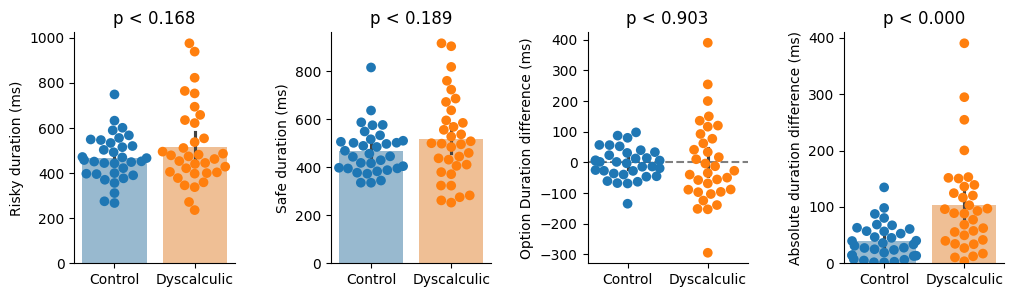

In [17]:
# difference fixations on risky vs safe?
from pingouin import pairwise_tests
tmp = df.groupby(['subject']).mean(numeric_only=True)
tmp['duration_option_difference_abs'] = tmp['duration_option_difference'].abs()
tmp['group'] = np.where(tmp['group'] == 0, 'Control', 'Dyscalculic')

fig, axs = plt.subplots(1, 4, figsize=(12,3))

for i, col in enumerate(['risky_duration', 'safe_duration', 'duration_option_difference','duration_option_difference_abs']):
    sns.barplot(tmp.reset_index(), y=col, x='group', hue='group',  ax=axs[i],legend=False,alpha=0.5)
    sns.swarmplot(tmp.reset_index(), y=col, x='group', hue='group',  ax=axs[i],legend=False,size=7)
    stats = pairwise_tests(tmp.reset_index(), dv=col, between='group')
    axs[i].set(title=f'p < {stats["p-unc"].values[0]:.3f}', xlabel=None)

axs[0].set_ylabel('Risky duration (ms)')
axs[1].set_ylabel('Safe duration (ms)')
axs[2].set_ylabel('Option Duration difference (ms)')
axs[3].set_ylabel('Absolute duration difference (ms)')

axs[2].axhline(0, color='k', linestyle='--', alpha=0.5)
sns.despine()
fig.subplots_adjust(wspace=0.6)
plt.savefig(op.join(plot_folder, f'risk_eyetrack_durations_options.pdf'), bbox_inches='tight')

## Correlations?

In [19]:
source_folder = '/Users/mrenke/data/ds-dnumrisk/derivatives/phenotype'

# risk symbolic: SS (stake size) RNP slope
ss_rnp_slope =  pd.read_csv(op.join(source_folder,f'risk_SS-RNP-subwise-MAPs_probit-2_format-symbolic.csv'))
ss_rnp_slope = ss_rnp_slope.set_index('subject').rename(columns={'slope':'ss_rnp_slope'})[['ss_rnp_slope']]

# eyetracking (only smybolic format)
format = 'non-symbolic'  # 'symbolic' or 'non-symbolic'
eyetrack_dur_diff = pd.read_csv(op.join(source_folder, f'subwise_duration_option_difference_abs_{format}.tsv')).set_index('subject')

# magjudge cognitive model
model_label =3 # 1 n1_evidence_sd & n2_evidence_sd, 3 = memory_noise_sd & perceptual_noise_sd
magjudge_bauer_params = pd.read_csv(op.join(source_folder,f'magjudge_bauer-{model_label}_sds.csv')).set_index('subject')

df_comb = ss_rnp_slope.join(eyetrack_dur_diff, on='subject').join(magjudge_bauer_params, on='subject')


In [20]:
df_comb.head()

,ss_rnp_slope,duration_option_difference_abs,memory_noise_sd,perceptual_noise_sd,group
subject,,,,,
1,0.004826,67.365079,0.128094,0.074870,0
2,0.018223,103.021277,0.222981,0.052561,1
3,0.014621,18.931937,0.137517,0.160089,0
4,0.012692,49.593750,0.178991,0.021833,1
5,0.011311,2.780749,0.130870,0.126985,0


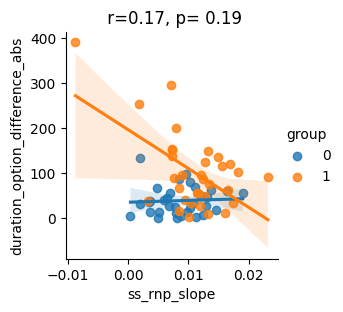

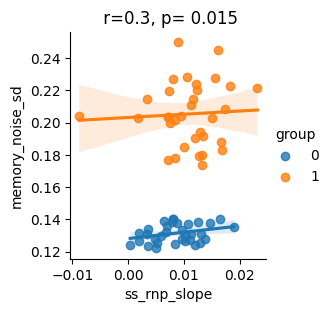

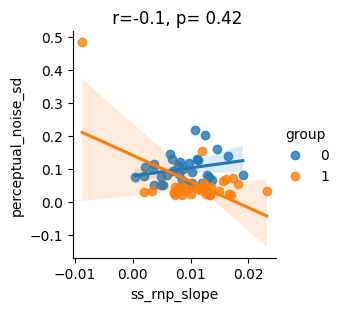

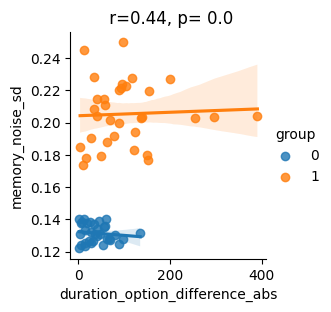

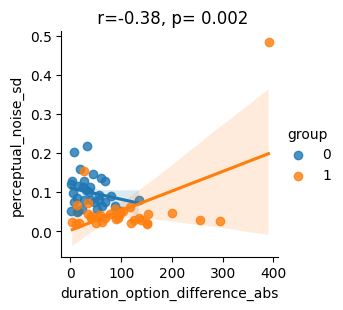

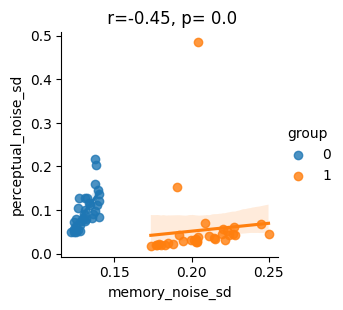

In [27]:
# correlate all variables in the dataframe
import itertools
import pingouin

#vars = df_comb.columns.drop(['group','gender'])
vars = df_comb.columns.drop(['group'])

for x_var, y_var in itertools.combinations(vars, 2):
    cor = pingouin.corr(df_comb[y_var], df_comb[x_var], method='shepherd')
    r_ = np.round(cor['r'][0], 2)
    p = np.round(cor['p-val'][0], 3)
    #print(f'{x_var} vs {y_var}: r={r_}, p= {p}')
    fig = sns.lmplot(x=x_var, y=y_var, data=df_comb,height=3,hue='group') #, hue='group' hue='group',
    fig.set(title=f' r={r_}, p= {p}') 

In [26]:
# test if more variance than group is explained from variables
import statsmodels.api as sm
from statsmodels.formula.api import ols

ind_var = 'memory_noise_sd'  # 'perceptual_noise_sd'  # 'ss_rnp_slope'  #
dep_var = 'duration_option_difference_abs'  # ['duration_option_difference_abs', 'ss_rnp_slope']  #
formula = f'{dep_var} ~ {ind_var} + group'

result = sm.formula.ols(formula=formula, data=df_comb.reset_index()).fit()

result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                  OLS Regression Results                                  
==========================================================================================
Dep. Variable:     duration_option_difference_abs   R-squared:                       0.202
Model:                                        OLS   Adj. R-squared:                  0.177
Method:                             Least Squares   F-statistic:                     7.972
Date:                            Wed, 01 Oct 2025   Prob (F-statistic):           0.000819
Time:                                    09:47:10   Log-Likelihood:                -367.05
No. Observations:                              66   AIC:                             740.1
Df Residuals:                                  63   BIC:                             746.7
Df Model:                                       2                                         
Covariance Type:                        nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          22.0245     74.088      0.297      0.767    -126.028     170.077
memory_noise_sd   132.1384    557.253      0.237      0.813    -981.444    1245.720
group              53.4687     44.140      1.211      0.230     -34.738     141.675
==============================================================================
Omnibus:                       42.504   Durbin-Watson:                   1.987
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              141.362
Skew:                           1.928   Prob(JB):                     2.01e-31
Kurtosis:                       9.044   Cond. No.                         82.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""